In [81]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import time
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.optimizers import RMSprop


# **Environment Setup**

In [46]:
#loaded the data both are the different files here train and test so thats why two different variables 
#because of two different files
train = pd.read_csv('/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_train.csv')
test = pd.read_csv('/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_test.csv')

In [47]:
#now its time to get the train and test data ready label column is target coulmn has values 0-9
#i will drop the label for train and test for X
X = train.drop('label', axis=1).values
y = train['label'].values

In [48]:
X_test = test.drop('label', axis=1).values
y_test = test['label'].values

In [49]:
#now i will normalize the values for this i recalled my ds concept to use minmax scalar
# scaler = MinMaxScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

#here i tried to use minmax scalar but by which i was getting a value of 1.3 in test.max() 
#but the assignment requirement was 0-1 so i divided it with max number 255

X = X / 255.0
X_test = X_test / 255.0

print("Training shape:", X.shape)
print("Test shape:", X_test.shape)
print("Training min:", X.min())
print("Training max:", X.max())
print("Test min:", X_test.min())
print("Test max:", X_test.max())

Training shape: (60000, 784)
Test shape: (10000, 784)
Training min: 0.0
Training max: 1.0
Test min: 0.0
Test max: 1.0


In [50]:
#data has already 784 columns so it is falattend already
print("X shape:", X.shape)
print("Test shape:", X_test.shape)

X shape: (60000, 784)
Test shape: (10000, 784)


In [51]:
#train test validation splitting 
#number of sample in each split
X_train, X_val, y_train, y_val = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)
print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Test samples:", len(X_test))

Training samples: 48000
Validation samples: 12000
Test samples: 10000


In [52]:
#class distritbution 0-9
print("\nTraining class distribution:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nValidation class distribution:")
print(pd.Series(y_val).value_counts().sort_index())

print("\nTest class distribution:")
print(pd.Series(y_test).value_counts().sort_index())


Training class distribution:
0    4800
1    4800
2    4800
3    4800
4    4800
5    4800
6    4800
7    4800
8    4800
9    4800
Name: count, dtype: int64

Validation class distribution:
0    1200
1    1200
2    1200
3    1200
4    1200
5    1200
6    1200
7    1200
8    1200
9    1200
Name: count, dtype: int64

Test class distribution:
0    1000
1    1000
2    1000
3    1000
4    1000
5    1000
6    1000
7    1000
8    1000
9    1000
Name: count, dtype: int64


# PART 1

In [53]:
# ReLU function for hidden layers
def relu(x):
    return np.maximum(0, x)

# Derivative of ReLU
def relu_derivative(x):
    return (x > 0).astype(float)

# Softmax for activation
def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

# one-hot encoding
def one_hot(y, classes):
    result = np.zeros((y.size, classes))
    result[np.arange(y.size), y] = 1
    return result

# Categorial Cross Entropy Loss Fucntion
def calculate_loss(y, output):
    m = y.shape[0]
    return -np.sum(y * np.log(output + 1e-15)) / m

In [54]:
np.random.seed(42)

#weights and bias
W1 = np.random.randn(784,64) * 0.01
b1 = np.zeros((1, 64))
W2 = np.random.randn(64, 10) * 0.01
b2 = np.zeros((1,10))


#i have to copy for torch
W1_initial = W1.copy()
b1_initial = b1.copy()
W2_initial = W2.copy()
b2_initial = b2.copy()

In [55]:
#Taking only 5000 training samples
X = X_train[0:5000]
y = y_train[0:5000]

#for pytorch need a copy
X_batch = X
y_batch = y

#one-hot encoding for categoeries
y_one_hot = one_hot(y, 10)


#here we will see the results of epochs after 5 iterations
epochs = 20
learning_rate = 0.1
losses = []
for epoch in range(epochs):
    #forward
    Z1 = np.dot(X, W1) + b1
    A1 = relu(Z1)
    Z2 = np.dot(A1, W2) + b2
    A2 = softmax(Z2)
    loss = calculate_loss(y_one_hot, A2)
    losses.append(loss)

    # Backpropagation
    m = X.shape[0]
    dZ2 = (A2 - y_one_hot) / m
    dW2 = np.dot(A1.T, dZ2)
    db2 = np.sum(dZ2, axis=0, keepdims=True)
    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = np.dot(X.T, dZ1)
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    #Update
    W1 = W1 - learning_rate * dW1
    b1 = b1 - learning_rate * db1
    W2 = W2 - learning_rate * dW2
    b2 = b2 - learning_rate * db2

    if (epoch + 1) % 5 == 0:
        print("Epoch:", epoch + 1, "Loss:", loss)

Epoch: 5 Loss: 2.2980597178845135
Epoch: 10 Loss: 2.2863589031136797
Epoch: 15 Loss: 2.262202776536237
Epoch: 20 Loss: 2.2150265810148526


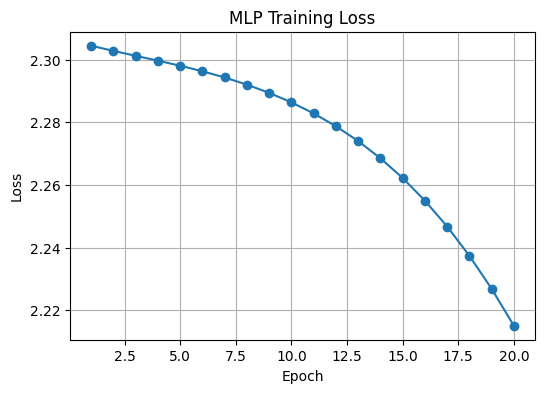

In [56]:
# Plot the loss
plt.figure(figsize=(6, 4))
plt.plot(range(1, epochs + 1), losses, marker='o')
plt.title("MLP Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()

In [57]:
#pytorch
model = nn.Sequential(nn.Linear(784, 64),nn.ReLU(),
    nn.Linear(64, 10))

#the copies i created in upper cell will be used here 
with torch.no_grad():
    model[0].weight.copy_(torch.tensor(W1_initial.T))
    model[0].bias.copy_(torch.tensor(b1_initial.flatten()))

    model[2].weight.copy_(torch.tensor(W2_initial.T))
    model[2].bias.copy_(torch.tensor(b2_initial.flatten()))

In [58]:
X_torch = torch.tensor(X_batch, dtype=torch.float32)
y_torch = torch.tensor(y_batch, dtype=torch.long)

#Forward
output = model(X_torch)

#loss
loss = nn.CrossEntropyLoss()(output, y_torch)

#Backward
loss.backward()

In [59]:
#pytorch gradiet
dW1_torch = model[0].weight.grad.numpy().T
dW2_torch = model[2].weight.grad.numpy().T

In [60]:
#absolute differ
difference_W1 = np.max(np.abs(dW1 - dW1_torch))
difference_W2 = np.max(np.abs(dW2 - dW2_torch))

print("Maximum difference for W1:", difference_W1)
print("Maximum difference for W2:", difference_W2)


Maximum difference for W1: 0.006655703195778628
Maximum difference for W2: 0.030647577130394975


# PART 2

In [61]:
np.random.seed(42)
tf.random.set_seed(42)

#encoding
y_train_cat = to_categorical(y_train, 10)
y_val_cat = to_categorical(y_val, 10)

In [62]:
X_grad_sample = X_val[0:128]
y_grad_sample = y_val_cat[0:128]

In [63]:
#this will get the gradient i get the issue and get to know
#fit() doesnt give me graident so this will get it
class GradientLogger(tf.keras.callbacks.Callback):
    def __init__(self, X_sample, y_sample):
        super().__init__()
        self.X_sample = X_sample
        self.y_sample = y_sample
        self.grad_history = []

    def on_epoch_end(self, epoch, logs=None):
        with tf.GradientTape() as tape:
            preds = self.model(self.X_sample, training=True)
            loss = tf.reduce_mean(tf.keras.losses.categorical_crossentropy(self.y_sample, preds))

        first_layer_w = self.model.layers[0].trainable_weights[0]
        grad = tape.gradient(loss, [first_layer_w])[0]
        self.grad_history.append(tf.reduce_mean(tf.abs(grad)).numpy())

In [64]:
#Sigmoid
sigmoid_model = Sequential([
    Dense(128, input_dim=784, activation='sigmoid'),
    Dense(64, activation='sigmoid'),
    Dense(10, activation='softmax')
])

sigmoid_model.compile(optimizer=Adam(learning_rate=0.001),
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

sigmoid_logger = GradientLogger(X_grad_sample, y_grad_sample)

sigmoid_history = sigmoid_model.fit(X_train, y_train_cat,
                                     validation_data=(X_val, y_val_cat),
                                     epochs=5, batch_size=128,
                                     callbacks=[sigmoid_logger],
                                     verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7207 - loss: 0.9422 - val_accuracy: 0.8076 - val_loss: 0.5576
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8302 - loss: 0.4878 - val_accuracy: 0.8392 - val_loss: 0.4460
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8514 - loss: 0.4193 - val_accuracy: 0.8495 - val_loss: 0.4085
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8627 - loss: 0.3862 - val_accuracy: 0.8581 - val_loss: 0.3889
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8707 - loss: 0.3645 - val_accuracy: 0.8616 - val_loss: 0.3759


In [65]:
#TANH
tanh_model = Sequential([
    Dense(128, input_dim=784, activation='tanh'),
    Dense(64, activation='tanh'),
    Dense(10, activation='softmax')
])

tanh_model.compile(optimizer=Adam(learning_rate=0.001),
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

tanh_logger = GradientLogger(X_grad_sample, y_grad_sample)

tanh_history = tanh_model.fit(X_train, y_train_cat,
                               validation_data=(X_val, y_val_cat),
                               epochs=5, batch_size=128,
                               callbacks=[tanh_logger],
                               verbose=1)

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8069 - loss: 0.5546 - val_accuracy: 0.8303 - val_loss: 0.4558
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8584 - loss: 0.3924 - val_accuracy: 0.8448 - val_loss: 0.4120
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8717 - loss: 0.3553 - val_accuracy: 0.8537 - val_loss: 0.3934
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8817 - loss: 0.3296 - val_accuracy: 0.8576 - val_loss: 0.3776
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8883 - loss: 0.3097 - val_accuracy: 0.8640 - val_loss: 0.3628


In [66]:
#RELU 
relu_model = Sequential([
    Dense(128, input_dim=784, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

relu_model.compile(optimizer=Adam(learning_rate=0.001),
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

relu_logger = GradientLogger(X_grad_sample, y_grad_sample)

relu_history = relu_model.fit(X_train, y_train_cat,
                               validation_data=(X_val, y_val_cat),
                               epochs=5, batch_size=128,
                               callbacks=[relu_logger],
                               verbose=1)

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7949 - loss: 0.5992 - val_accuracy: 0.8398 - val_loss: 0.4435
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8546 - loss: 0.4120 - val_accuracy: 0.8486 - val_loss: 0.4085
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8688 - loss: 0.3688 - val_accuracy: 0.8379 - val_loss: 0.4283
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8781 - loss: 0.3412 - val_accuracy: 0.8437 - val_loss: 0.4107
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8860 - loss: 0.3197 - val_accuracy: 0.8510 - val_loss: 0.3967


In [67]:
#LEAKY RELU 
leaky_model = Sequential([
    Dense(128, input_dim=784),
    LeakyReLU(alpha=0.01),
    Dense(64),
    LeakyReLU(alpha=0.01),
    Dense(10, activation='softmax')
])

leaky_model.compile(optimizer=Adam(learning_rate=0.001),
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

leaky_logger = GradientLogger(X_grad_sample, y_grad_sample)

leaky_history = leaky_model.fit(X_train, y_train_cat,
                                 validation_data=(X_val, y_val_cat),
                                 epochs=5, batch_size=128,
                                 callbacks=[leaky_logger],
                                 verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8004 - loss: 0.5782 - val_accuracy: 0.8338 - val_loss: 0.4630
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8565 - loss: 0.4053 - val_accuracy: 0.8407 - val_loss: 0.4325
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8695 - loss: 0.3635 - val_accuracy: 0.8457 - val_loss: 0.4128
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8790 - loss: 0.3362 - val_accuracy: 0.8481 - val_loss: 0.4046
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8857 - loss: 0.3161 - val_accuracy: 0.8499 - val_loss: 0.3971


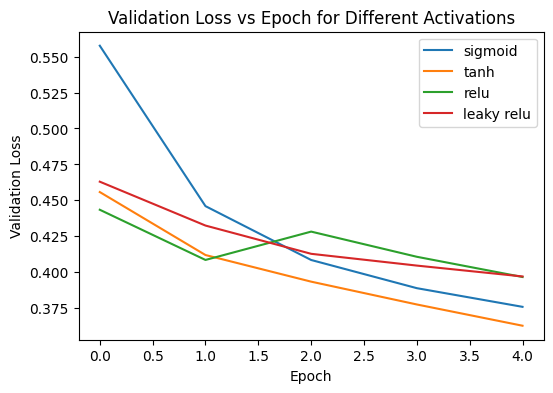

In [68]:
# plotting all 4 val loss curves together
plt.figure(figsize=(6,4))
plt.plot(sigmoid_history.history['val_loss'], label='sigmoid')
plt.plot(tanh_history.history['val_loss'], label='tanh')
plt.plot(relu_history.history['val_loss'], label='relu')
plt.plot(leaky_history.history['val_loss'], label='leaky relu')

plt.title("Validation Loss vs Epoch for Different Activations")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.show()

In [69]:
#epoch 1 and last
print("sigmoid grad epoch 1:", sigmoid_logger.grad_history[0])
print("sigmoid grad last epoch:", sigmoid_logger.grad_history[-1])

print("relu grad epoch 1:", relu_logger.grad_history[0])
print("relu grad last epoch:", relu_logger.grad_history[-1])

sigmoid grad epoch 1: 0.000237104
sigmoid grad last epoch: 0.00036153913
relu grad epoch 1: 0.0014074856
relu grad last epoch: 0.0023283118


so by this we can see that for the sigmoid the learning is very less as compared to the relu as there is difference in both values for sigmoid and relu

so in short words the relu provides a better learning as compared to the sigmoid


In [70]:
#if output is 0 it is dead relu
W1_relu, b1_relu = relu_model.layers[0].get_weights()

Z1 = np.dot(X_val[:256], W1_relu) + b1_relu
A1 = relu(Z1)   #relu from p1

dead_units = np.all(A1 == 0, axis=0) #check all
dead_percentage = np.mean(dead_units) * 100
print("percentage of dead relu units:", dead_percentage, "%")

percentage of dead relu units: 6.25 %


3.9% are 0 this is very small ratio and i think it is not that concerning but to name it this is the dying relu problem for which solution exists but here the number is small so we will ignore it the solution to solve the dying relu problem is >* Leaky Relu (0.01x,x)*

# PART 3

here i am using sample data set of diabetes which i explored on
https://scikit-learn.org/stable/datasets/toy_dataset.html

In [71]:
#CROSS ENTROPY MODEL
#using the same relu architecture from part 2 (128, 64)
ce_model = Sequential([
    Dense(784, input_dim=784, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

ce_model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

ce_history = ce_model.fit(X_train, y_train_cat,
                           validation_data=(X_val, y_val_cat),
                           epochs=5, batch_size=128,
                           verbose=1)

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8147 - loss: 0.5278 - val_accuracy: 0.8478 - val_loss: 0.4215
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8645 - loss: 0.3802 - val_accuracy: 0.8602 - val_loss: 0.3802
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8791 - loss: 0.3366 - val_accuracy: 0.8471 - val_loss: 0.4037
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8870 - loss: 0.3103 - val_accuracy: 0.8469 - val_loss: 0.4101
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8940 - loss: 0.2907 - val_accuracy: 0.8544 - val_loss: 0.3925


In [72]:
y_test_cat = to_categorical(y_test, 10)

ce_test_loss, ce_test_acc = ce_model.evaluate(X_test, y_test_cat, verbose=0)
print("cross entropy test accuracy:", ce_test_acc)

cross entropy test accuracy: 0.8561999797821045


In [73]:
#MSE MODEL 
#same as above only loss function differ
mse_model = Sequential([
    Dense(784, input_dim=784, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

mse_model.compile(optimizer=Adam(learning_rate=0.001),
                   loss='mean_squared_error',
                   metrics=['accuracy'])

mse_history = mse_model.fit(X_train, y_train_cat,
                             validation_data=(X_val, y_val_cat),
                             epochs=5, batch_size=128,
                             verbose=1)

mse_test_loss, mse_test_acc = mse_model.evaluate(X_test, y_test_cat, verbose=0)
print("mse test accuracy:", mse_test_acc)

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8143 - loss: 0.0270 - val_accuracy: 0.8390 - val_loss: 0.0234
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8597 - loss: 0.0205 - val_accuracy: 0.8442 - val_loss: 0.0220
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8755 - loss: 0.0183 - val_accuracy: 0.8468 - val_loss: 0.0214
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8842 - loss: 0.0171 - val_accuracy: 0.8623 - val_loss: 0.0202
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8901 - loss: 0.0163 - val_accuracy: 0.8689 - val_loss: 0.0190
mse test accuracy: 0.8687999844551086


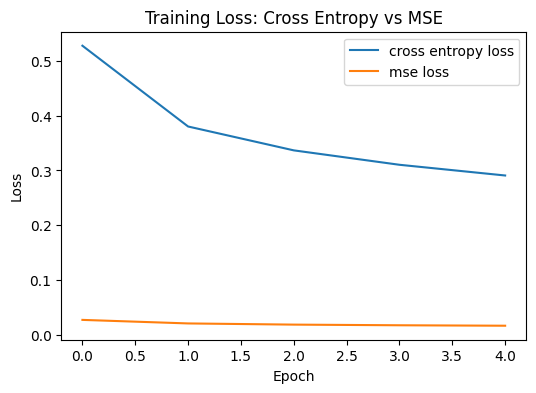

In [74]:
plt.figure(figsize=(6,4))
plt.plot(ce_history.history['loss'], label='cross entropy loss')
plt.plot(mse_history.history['loss'], label='mse loss')
plt.title("Training Loss: Cross Entropy vs MSE")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

**Diabetes DataSet**

In [75]:
diabetes = load_diabetes()
X_diab = diabetes.data
y_diab = diabetes.target

print("X shape:", X_diab.shape)
print("y sample:", y_diab[0:5])

X shape: (442, 10)
y sample: [151.  75. 141. 206. 135.]


In [76]:
X_diab_train, X_diab_test, y_diab_train, y_diab_test = train_test_split(
    X_diab, y_diab, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_diab_train = scaler.fit_transform(X_diab_train)
X_diab_test = scaler.transform(X_diab_test)

In [77]:
reg_model = Sequential([
    Dense(40, input_dim=X_diab_train.shape[1], activation='relu'),
    Dense(20, activation='relu'),
    Dense(1)  #no activation function as this is regression
])

reg_model.compile(optimizer=Adam(learning_rate=0.01),
                   loss='mse',
                   metrics=['mae'])

reg_history = reg_model.fit(X_diab_train, y_diab_train,
                             validation_split=0.2,
                             epochs=50, batch_size=20,
                             verbose=1)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 30474.6875 - mae: 155.5166 - val_loss: 20076.8789 - val_mae: 125.2638
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 23886.8652 - mae: 134.7525 - val_loss: 12121.7510 - val_mae: 91.5546
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 10187.0234 - mae: 78.9469 - val_loss: 4397.4087 - val_mae: 50.9942
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6343.9131 - mae: 62.3615 - val_loss: 3644.0364 - val_mae: 45.9580
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4273.3174 - mae: 51.4649 - val_loss: 3340.2773 - val_mae: 42.7808
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3691.8306 - mae: 48.0620 - val_loss: 2933.4675 - val_mae: 41.7156
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3319.3662 - mae: 45.7982 - val_loss: 2818.2166 - val_mae: 41.1267
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3164.0986 - mae: 44.9164 - val_loss: 2764.1995 - val_mae: 41.4864
Epoch 9/50

In [78]:
y_diab_pred = reg_model.predict(X_diab_test)

mse_val = mean_squared_error(y_diab_test, y_diab_pred)
rmse_val = np.sqrt(mse_val)
mae_val = mean_absolute_error(y_diab_test, y_diab_pred)

print("MSE:", mse_val)
print("RMSE:", rmse_val)
print("MAE:", mae_val)

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/stepWARNING:tensorflow:6 out of the last 9 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x7fc7276eb560> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
MSE: 2608.566027516522
RMSE: 51.07412287564537
MAE: 41.124245032835546


When the MSE is combined with softmax it produces small gradients so by this the learning becomes slow but on the other hand corss-entropy with softmax the output is large as compared to MSE so it pushes the weights towards the correct answer

# PART 4

In [79]:
#Optimsers
def epochs_to_reach(history, target=0.85):
    val_acc = history.history['val_accuracy']

    epoch = 1

    for acc in val_acc:
        if acc >= target:
            return epoch
        epoch += 1

    return None
#loop for tracking epochs catch when accuracy gets 85

In [82]:
#SGD plain
sgd_model = Sequential([
    Dense(784, input_dim=784, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

sgd_model.compile(optimizer=SGD(learning_rate=0.01),
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

start = time.time()
sgd_history = sgd_model.fit(X_train, y_train_cat,
                             validation_data=(X_val, y_val_cat),
                             epochs=20, batch_size=100,
                             verbose=1)
sgd_time = time.time() - start

print("sgd epochs to 85%:", epochs_to_reach(sgd_history))
print("sgd final val acc:", sgd_history.history['val_accuracy'][-1])
print("sgd wall clock time:", sgd_time)

Epoch 1/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.6974 - loss: 0.9914 - val_accuracy: 0.7732 - val_loss: 0.6822
Epoch 2/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8013 - loss: 0.6065 - val_accuracy: 0.8037 - val_loss: 0.5723
Epoch 3/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8216 - loss: 0.5327 - val_accuracy: 0.8112 - val_loss: 0.5282
Epoch 4/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8313 - loss: 0.4955 - val_accuracy: 0.8167 - val_loss: 0.5036
Epoch 5/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8374 - loss: 0.4716 - val_accuracy: 0.8212 - val_loss: 0.4874
Epoch 6/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8418 - loss: 0.4540 - val_accuracy: 0.8242 - val_loss: 0.4758
Epoch 7/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8457 - loss: 0.4401 - val_accuracy: 0.8273 - val_loss: 0.4663
Epoch 8/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8496 - loss: 0.4285 - val_accuracy: 0.

In [84]:
#SGD with momentum

sgd_mom_model = Sequential([
    Dense(784, input_dim=784, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

sgd_mom_model.compile(optimizer=SGD(learning_rate=0.01, momentum=0.9),
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

start = time.time()
sgd_mom_history = sgd_mom_model.fit(X_train, y_train_cat,
                                     validation_data=(X_val, y_val_cat),
                                     epochs=20, batch_size=100,
                                     verbose=1)
sgd_mom_time = time.time() - start

print("sgd+momentum epochs to 85%:", epochs_to_reach(sgd_mom_history))
print("sgd+momentum final val acc:", sgd_mom_history.history['val_accuracy'][-1])
print("sgd+momentum wall clock time:", sgd_mom_time)

Epoch 1/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7872 - loss: 0.6212 - val_accuracy: 0.8309 - val_loss: 0.4730
Epoch 2/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8481 - loss: 0.4308 - val_accuracy: 0.8471 - val_loss: 0.4198
Epoch 3/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8640 - loss: 0.3845 - val_accuracy: 0.8583 - val_loss: 0.3865
Epoch 4/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8733 - loss: 0.3553 - val_accuracy: 0.8611 - val_loss: 0.3739
Epoch 5/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8804 - loss: 0.3326 - val_accuracy: 0.8620 - val_loss: 0.3660
Epoch 6/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8869 - loss: 0.3141 - val_accuracy: 0.8652 - val_loss: 0.3565
Epoch 7/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8924 - loss: 0.2987 - val_accuracy: 0.8667 - val_loss: 0.3532
Epoch 8/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8982 - loss: 0.2846 - val_accuracy: 0.

In [88]:
#RMSProp
rms_model = Sequential([
    Dense(784, input_dim=784, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

rms_model.compile(optimizer=RMSprop(learning_rate=0.01),
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

start = time.time()
rms_history = rms_model.fit(X_train, y_train_cat,
                             validation_data=(X_val, y_val_cat),
                             epochs=20, batch_size=100,
                             verbose=1)
rms_time = time.time() - start

print("rmsprop epochs to 85%:", epochs_to_reach(rms_history))
print("rmsprop final val acc:", rms_history.history['val_accuracy'][-1])
print("rmsprop wall clock time:", rms_time)

Epoch 1/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.7468 - loss: 0.9780 - val_accuracy: 0.7514 - val_loss: 0.9577
Epoch 2/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8300 - loss: 0.4752 - val_accuracy: 0.7979 - val_loss: 0.5141
Epoch 3/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8454 - loss: 0.4372 - val_accuracy: 0.8242 - val_loss: 0.4570
Epoch 4/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8515 - loss: 0.4239 - val_accuracy: 0.8378 - val_loss: 0.4385
Epoch 5/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8562 - loss: 0.4091 - val_accuracy: 0.8404 - val_loss: 0.4487
Epoch 6/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8603 - loss: 0.3999 - val_accuracy: 0.8451 - val_loss: 0.4619
Epoch 7/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8638 - loss: 0.3952 - val_accuracy: 0.8415 - val_loss: 0.4635
Epoch 8/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8652 - loss: 0.3934 - val_accuracy: 0.

In [87]:
#Adam
adam_model = Sequential([
    Dense(784, input_dim=784, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

adam_model.compile(optimizer=Adam(learning_rate=0.01),
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

start = time.time()
adam_history = adam_model.fit(X_train, y_train_cat,
                               validation_data=(X_val, y_val_cat),
                               epochs=20, batch_size=100,
                               verbose=1)
adam_time = time.time() - start

print("adam epochs to 85%:", epochs_to_reach(adam_history))
print("adam final val acc:", adam_history.history['val_accuracy'][-1])
print("adam wall clock time:", adam_time)

Epoch 1/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7862 - loss: 0.6581 - val_accuracy: 0.8227 - val_loss: 0.4736
Epoch 2/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8510 - loss: 0.4125 - val_accuracy: 0.8387 - val_loss: 0.4276
Epoch 3/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8605 - loss: 0.3836 - val_accuracy: 0.8407 - val_loss: 0.4234
Epoch 4/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8706 - loss: 0.3591 - val_accuracy: 0.8466 - val_loss: 0.4267
Epoch 5/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8734 - loss: 0.3475 - val_accuracy: 0.8432 - val_loss: 0.4150
Epoch 6/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8808 - loss: 0.3295 - val_accuracy: 0.8447 - val_loss: 0.4384
Epoch 7/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8816 - loss: 0.3288 - val_accuracy: 0.8432 - val_loss: 0.4429
Epoch 8/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8856 - loss: 0.3162 - val_accuracy: 0